# Curie temperature estimation

The Curie temperature (*T*$_c$) is the temperature at which a ferromagnetic (*sensu lato*) mineral undergoes the transition to a paramagnetic state. Because *T*$_c$ varies systematically with composition within solid-solution series such as the titanomagnetites, it is one of the most diagnostic rock magnetic parameters for magnetic mineralogy. However, estimates of *T*$_c$ from thermomagnetic data are method-dependent and data-type-dependent, with systematic offsets of several to tens of degrees between methods applied to the same curve ([Lattard et al., 2006](https://doi.org/10.1029/2006JB004591); [Fabian et al., 2013](https://doi.org/10.1029/2012GC004440)). This notebook demonstrates the estimation methods implemented in `rockmag.py`, their physical basis, and the caveats that attend each of them.

## Method overview

The analysis of [Fabian et al. (2013)](https://doi.org/10.1029/2012GC004440), grounded in the Landau theory of second-order phase transitions with an explicit field term, provides the framework. For a magnetization curve *M*(*T*) measured in an applied field, the Curie temperature corresponds to the **inflection point** of the curve (the minimum of d*M*/d*T*), a position that is effectively independent of the applied field. The classical estimators — the **maximum curvature** method ("the temperature at which the curvature of the concave part of the heating curve is a maximum"; Ade-Hall et al., 1965) and the **two-tangent** method of [Grommé et al. (1969)](https://doi.org/10.1029/JB074i022p05277) — coincide with each other and lie systematically *above* the inflection-point *T*$_c$, typically by 10–15 °C, with the offset increasing with field strength.

Low-field susceptibility $\chi$(*T*) requires separate treatment. At least four physical processes contribute to the initial susceptibility near the ordering temperature (variation of *M*$_s$ with field, rotation against anisotropy, domain-wall motion, and superparamagnetism), so the shape of $\chi$(*T*) near *T*$_c$ is strongly grain-size dependent, and a Hopkinson peak marks the blocking temperature rather than *T*$_c$. For $\chi$(*T*) data, [Petrovský and Kapička (2006)](https://doi.org/10.1029/2006JB004507) showed that the two-tangent method lacks a rigorous physical basis and can considerably overestimate *T*$_c$; they advocate the **inverse susceptibility** approach, in which 1/$\chi$ above the transition is extrapolated to zero via the Curie-Weiss law — with the caveat that this yields the paramagnetic Curie temperature $\theta \geq$ *T*$_c$.

| method | intended data | what it locates | key caveat |
|---|---|---|---|
| `inflection` | in-field *M*(*T*) | *T*$_c$ (Landau theory) | requires smoothing; derivatives amplify noise |
| `max_curvature` | *M*(*T*) | practical *T*$_c$ of Ade-Hall et al. (1965) | above inflection-point *T*$_c$ by ~10–15 °C; field-dependent |
| `two_tangent` | *M*(*T*) | graphical "knee" (Grommé et al., 1969) | coincides with max curvature; lacks a rigorous basis on $\chi$(*T*) |
| `inverse_susceptibility` | $\chi$(*T*) | paramagnetic Curie temperature $\theta$ | $\theta \geq$ *T*$_c$; sensitive to the fitting window |
| `landau` | in-field *M*(*T*) | *T*$_c$ with formal uncertainty (Fabian et al., 2013) | single phase measured through its transition |
| `ms_squared_extrapolation` | *M*(*T*) that ends below *T*$_c$ | *T*$_c$ by extrapolating *M*$_s^2 \rightarrow$ 0 ([Moskowitz, 1981](https://doi.org/10.1016/0012-821X(81)90028-5)) | reliability decays with distance below *T*$_c$; highest-*T*$_c$ phase only |

All of these are available through individual functions (`rmag.curie_derivative_estimates`, `rmag.curie_two_tangent`, `rmag.curie_inverse_susceptibility`, `rmag.curie_landau_fit`, `rmag.curie_Ms_squared_extrapolation`) that operate on plain temperature/magnetization arrays, and through the wrapper `rmag.curie_temperature_estimates` that takes a MagIC-formatted experiment DataFrame and returns a tidy comparison table.

## Install and import packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pmagpy.rockmag as rmag
import pmagpy.ipmag as ipmag
import pmagpy.contribution_builder as cb

from bokeh.io import output_notebook
output_notebook(hide_banner=True)

## Import data

The examples in this notebook use data from the [Rock Magnetic Bestiary](https://www2.irm.umn.edu/bestiary) contribution to the MagIC database that includes measurements on synthetic magnetite, titanomagnetite, and maghemite samples. We follow the approach of the `rockmag_data_unpack.ipynb` notebook to bring the MagIC data into the notebook as a contribution.

The `rmag.make_experiment_df` helper tabulates the unique specimen/method/experiment combinations in the measurements table; inspecting it (or using the selection widgets shown in the companion notebooks) is how the experiment names used by name below can be found.

In [2]:
# define these three parameters to match your data
# (the same contribution is used by high_T_susceptibility.ipynb, so the
# download is shared with that notebook's data directory)
magic_id = '20354'
share_key = '2f33e164-df55-4548-8d28-5b715683ae43'
dir_path = 'example_data/X-T'

result, magic_file = ipmag.download_magic_from_id(magic_id, directory=dir_path, share_key=share_key)
ipmag.unpack_magic(magic_file, dir_path, print_progress=False)
contribution = cb.Contribution(dir_path)
measurements = contribution.tables['measurements'].df
experiments = rmag.make_experiment_df(measurements)

Download successful. File saved to: example_data/X-T/magic_contribution_20354.txt
1  records written to file  /Users/penokean/0000_GitHub/RockmagPy-notebooks/thermomagnetic_notebooks/example_data/X-T/contribution.txt
2  records written to file  /Users/penokean/0000_GitHub/RockmagPy-notebooks/thermomagnetic_notebooks/example_data/X-T/locations.txt
2  records written to file  /Users/penokean/0000_GitHub/RockmagPy-notebooks/thermomagnetic_notebooks/example_data/X-T/sites.txt
43  records written to file  /Users/penokean/0000_GitHub/RockmagPy-notebooks/thermomagnetic_notebooks/example_data/X-T/samples.txt
201  records written to file  /Users/penokean/0000_GitHub/RockmagPy-notebooks/thermomagnetic_notebooks/example_data/X-T/specimens.txt


92035  records written to file  /Users/penokean/0000_GitHub/RockmagPy-notebooks/thermomagnetic_notebooks/example_data/X-T/measurements.txt


-I- Using cached data model


-I- Getting method codes from earthref.org


-I- Importing controlled vocabularies from https://earthref.org


## Part 1: Curie temperature from magnetization *M*(*T*) data

Strong-field thermomagnetic curves — from a Curie balance or a vibrating sample magnetometer (VSM) — measure the induced magnetization through the transition and are the preferred data type for quantitative *T*$_c$ estimation. The per-method estimator functions operate on plain arrays, so data from any acquisition stream can be analyzed. Here we use a classic Curie balance heating curve that has long shipped with PmagPy as `curie_example.dat` (a plain two-column temperature/magnetization file), which allows direct comparison with the legacy `ipmag.curie` function.

Each estimator returns a dictionary with the estimate itself (`curie_temp`, plus `curie_temp_stderr` where the method provides a formal uncertainty), a `params` dictionary of fit parameters, and a `diagnostics` dictionary of arrays (derivatives, fitted lines, model curves) for plotting — used to build the figure below. The derivative estimator instead names its two estimates `inflection_temp` and `max_curvature_temp`.

In [3]:
T, M = np.loadtxt('../example_data/curie/curie_example.dat', unpack=True)

# smooth with a 10 degree moving window prior to differentiation
sT, sM = rmag.smooth_moving_average(T, M, 10)

derivative_result = rmag.curie_derivative_estimates(sT, sM, smooth_window=10)
two_tangent_result = rmag.curie_two_tangent(sT, sM)
landau_result = rmag.curie_landau_fit(sT, sM, temp_unit='C')

print(f"inflection point:      {derivative_result['inflection_temp']:.1f} °C")
print(f"maximum curvature:     {derivative_result['max_curvature_temp']:.1f} °C")
print(f"two-tangent:           {two_tangent_result['curie_temp']:.1f} °C")
print(f"Landau fit:            {landau_result['curie_temp']:.1f} ± {landau_result['curie_temp_stderr']:.1f} °C  (h = {landau_result['params']['h']:.2e})")

inflection point:      480.3 °C
maximum curvature:     548.2 °C
two-tangent:           541.2 °C
Landau fit:            547.8 ± 2.4 °C  (h = 1.56e-04)


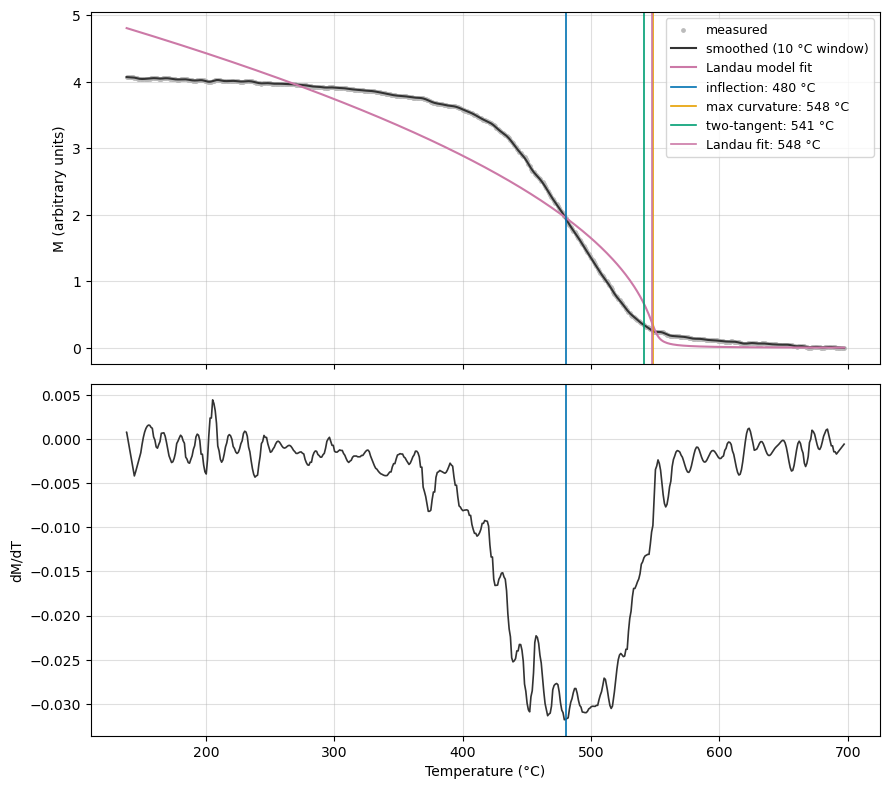

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax1.scatter(T, M, s=6, color='#bbbbbb', label='measured')
ax1.plot(sT, sM, color='#333333', lw=1.5, label='smoothed (10 °C window)')
ax1.plot(landau_result['diagnostics']['model_T'], landau_result['diagnostics']['model_M'],
         color='#CC79A7', lw=1.5, label='Landau model fit')
for temp, label, color in [
        (derivative_result['inflection_temp'], 'inflection', '#0072B2'),
        (derivative_result['max_curvature_temp'], 'max curvature', '#E69F00'),
        (two_tangent_result['curie_temp'], 'two-tangent', '#009E73'),
        (landau_result['curie_temp'], 'Landau fit', '#CC79A7')]:
    ax1.axvline(temp, color=color, lw=1.2, label=f'{label}: {temp:.0f} °C')
ax1.set_ylabel('M (arbitrary units)')
ax1.legend(fontsize=9)

d = derivative_result['diagnostics']
ax2.plot(d['T'], d['dy_dT'], color='#333333', lw=1.2)
ax2.axvline(derivative_result['inflection_temp'], color='#0072B2', lw=1.2)
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('dM/dT')
for ax in (ax1, ax2):
    ax.grid(alpha=0.4)
plt.tight_layout();

### Interpreting the spread of estimates

The estimates span nearly 70 °C, and the spread itself is informative. The two-tangent (~541 °C), Landau-fit (~548 °C), and maximum-curvature (~548 °C) estimates cluster near the "knee" of the curve, while the inflection point (minimum of d*M*/d*T*, ~480 °C) sits well below it. For an ideal single-phase sample the estimates would differ by only 10–15 °C, with the inflection point lowest and the maximum-curvature and two-tangent estimates approximately coincident above it. The much larger spread here is consistent with a distribution of Curie temperatures in this natural sample (e.g., variable titanium substitution): a *T*$_c$ distribution broadens and flattens the steepest-descent region of the aggregate curve, so the inflection sits well below the knee — where the last ferromagnetic contribution vanishes and which traces the upper end of the distribution ([Fabian et al., 2013](https://doi.org/10.1029/2012GC004440)). Comparing methods therefore provides a diagnostic of sample homogeneity that no single estimate conveys.

The reduced field *h* printed with the Landau fit is the model's dimensionless applied-field parameter: it rounds the transition and generates the field-induced magnetization tail that persists above *T*$_c$, which is why the fit needs no ad-hoc baseline subtraction.

Because differentiation amplifies noise, the first and second derivatives are smoothed on the same 10 °C scale as the signal (the `smooth_window` argument) before their extrema are located, so the inflection is placed at the center of the broad steepest-descent region rather than at an arbitrary point-to-point noise spike within it. Note the distinction between the two uses of the 10 °C window in the code above: `smooth_moving_average` smooths the *signal* once, while `smooth_window=10` inside `curie_derivative_estimates` smooths the *derivatives* computed from it.

For reference, the legacy `ipmag.curie` function (second-derivative maximum after Bartlett smoothing on a resampled 1 °C grid) yields 552 °C on this file with the same window — consistent with the `max_curvature` estimate here (~548 °C), which supersedes it.

### When the run ends below *T*$_c$: *M*$_s^2$ extrapolation

Some samples cannot be measured through their transition — the classic case being titanomaghemites that chemically invert upon heating before *M*$_s$ reaches zero. For such curves, [Moskowitz (1981)](https://doi.org/10.1016/0012-821X(81)90028-5) proposed extrapolating on the basis that near *T*$_c$, mean-field theory gives *M*$_s \propto$ (*T*$_c$ $-$ *T*)$^{1/2}$, so *M*$_s^2$ is linear in temperature and extrapolates to zero at *T*$_c$. The `curie_Ms_squared_extrapolation` function implements this.

To illustrate both the method and its central caveat, we truncate the example curve at 500 °C — as if the measurement had ended there — and extrapolate from the descending limb:

In [5]:
truncated = sT <= 500
ms2_result = rmag.curie_Ms_squared_extrapolation(sT[truncated], sM[truncated],
                                                 fit_range=(430, 500))
print(f"Ms^2 extrapolation (truncated at 500 °C): "
      f"{ms2_result['curie_temp']:.1f} ± {ms2_result['curie_temp_stderr']:.1f} °C "
      f"(r^2 = {ms2_result['params']['r_squared']:.3f})")

Ms^2 extrapolation (truncated at 500 °C): 510.3 ± 0.4 °C (r^2 = 0.996)


The fit is excellent statistically (*r*$^2 \approx$ 0.996) yet the extrapolated *T*$_c$ of ~510 °C falls well short of the ~548 °C obtained from the full curve — precisely because this sample has a distribution of Curie temperatures, so the descending limb available below 500 °C is not the mean-field tail of the highest-*T*$_c$ phase. This is the caveat to carry: the extrapolation is exact for an ideal mean-field single phase (Moskowitz reported ±5 °C on Fe$_3$O$_4$, Ni, and CrO$_2$ standards), but its reliability decays with the distance between the last measured point and *T*$_c$, a goodness-of-fit statistic does not capture that model error, and for multiphase samples only the highest-*T*$_c$ phase is (at best) recovered. Report the fitting window with the estimate, and prefer through-transition data whenever the sample allows it.

## Part 2: Curie temperature from susceptibility $\chi$(*T*) data

High-temperature susceptibility (χ-T) curves measured on a Kappabridge pass fully through the transition and are the most common thermomagnetic data type. As laid out in the method overview, the shape of $\chi$(*T*) near *T*$_c$ convolves several susceptibility mechanisms, so estimates from $\chi$(*T*) require more care than those from *M*(*T*). Here we analyze the χ-T curve for a synthetic magnetite (Wright Company sample 112982) from the Rock Magnetic Bestiary.

### Choosing a smoothing window

Derivative-based estimators amplify measurement noise, so the data are smoothed with a temperature-space moving window prior to differentiation. The choice of window width trades noise reduction against distortion of the curve; `rmag.optimize_moving_average_window` sweeps window widths and plots the residual roughness (average RMS) against the within-window variance so that a window at the "knee" of the trade-off can be chosen. For these data a ~10 °C window is a reasonable choice.

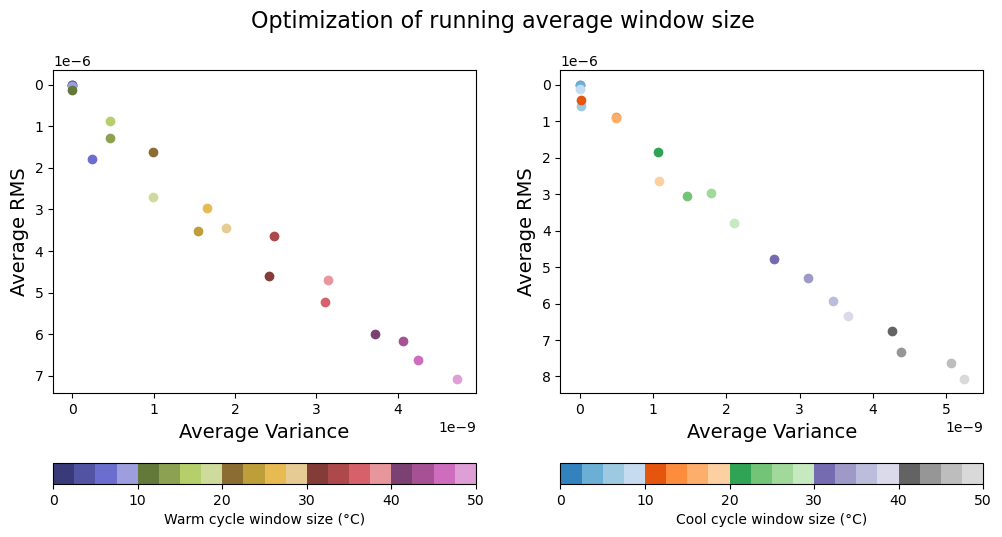

In [6]:
selected_experiment = measurements[measurements['experiment'] ==
                                   'IRM-KappaF-LP-X-T-3410'].reset_index(drop=True)

fig, axs = rmag.optimize_moving_average_window(selected_experiment, min_temp_window=0,
                                               max_temp_window=50, steps=20)

### Choosing the Curie-Weiss fitting window: resolution matters

The Curie-Weiss fit must be restricted to temperatures where the signal is fully paramagnetic *and* still resolved by the instrument. Above the transition the holder-corrected susceptibility of this specimen collapses rapidly toward the measurement resolution of the Kappabridge: by ~625 °C the signal is pinned at the last one or two counts of the meter, producing flat quantized plateaus in 1/$\chi$. Including such resolution-limited points flattens the fitted slope and biases $\theta$ low. A naive wide window demonstrates the failure — and the function detects it:

In [7]:
heating = rmag.prepare_thermomag_branches(selected_experiment, smooth_window=10)['heating']

naive_fit = rmag.curie_inverse_susceptibility(heating['T'], heating['y'], fit_range=(600, 700))
print(f"theta (600-700 °C window): {naive_fit['curie_temp']:.1f} ± {naive_fit['curie_temp_stderr']:.1f} °C")
print(f"warning: {naive_fit['params']['warning']}")

theta (600-700 °C window): 564.6 ± 9.3 °C


The naive window returns $\theta \approx$ 565 °C — *below* the inflection-point estimate of the Curie temperature. Since theory requires $\theta \geq$ *T*$_c$, a Curie-Weiss $\theta$ that falls below an independent *T*$_c$ estimate is itself a red flag that the fit is contaminated. Restricting the window to the interval where 1/$\chi$ is linear and the signal remains resolved above the quantization floor recovers a fit that is both statistically better and physically consistent. Here that interval is 585–606 °C, identified by inspecting where 1/$\chi$ is linear before the quantized plateaus begin — the interactive fitting tool demonstrated below is designed for exactly this. (Alternatively, the `min_chi` argument of `curie_inverse_susceptibility` screens out points below a susceptibility floor, such as a few instrument counts.)

### Estimates from all methods, with the comparison table

`rmag.curie_temperature_estimates` applies the requested methods to the heating and cooling branches and returns a tidy DataFrame. The default method set depends on the data type, which is inferred from the `magnetic_column` name (columns containing `susc` or `chi` are treated as susceptibility; pass `data_type` to override): susceptibility data default to `inflection`, `max_curvature`, and `inverse_susceptibility`, while magnetization data default to `inflection`, `max_curvature`, `two_tangent`, and `landau`.

Per-method options are passed through `method_kwargs`, a dictionary keyed by method name whose values are keyword arguments forwarded to that method's function — for example `{'inverse_susceptibility': {'fit_range': (585, 606)}}` below, or `{'landau': {'fit_range': (300, 650)}}`. The Curie-Weiss fit window is set explicitly — the window is part of the analysis and should be reported alongside the estimate.

In [8]:
curie_estimates = rmag.curie_temperature_estimates(
    selected_experiment,
    smooth_window=10,
    method_kwargs={'inverse_susceptibility': {'fit_range': (585, 606)}},
)
curie_estimates[['branch', 'method', 'curie_temp', 'curie_temp_stderr', 'temp_unit', 'notes']]

,branch,method,curie_temp,curie_temp_stderr,temp_unit,notes
0,heating,inflection,576.674623,NaN,C,inflection point (minimum of dy/dT); for in-fi...
1,heating,max_curvature,580.950000,NaN,C,maximum-curvature estimate on susceptibility l...
2,heating,inverse_susceptibility,586.795836,0.740622,C,Curie-Weiss extrapolation of 1/chi; yields the...
3,cooling,inflection,572.164202,NaN,C,inflection point (minimum of dy/dT); for in-fi...
4,cooling,max_curvature,575.750000,NaN,C,maximum-curvature estimate on susceptibility l...
5,cooling,inverse_susceptibility,584.067157,1.399497,C,Curie-Weiss extrapolation of 1/chi; yields the...


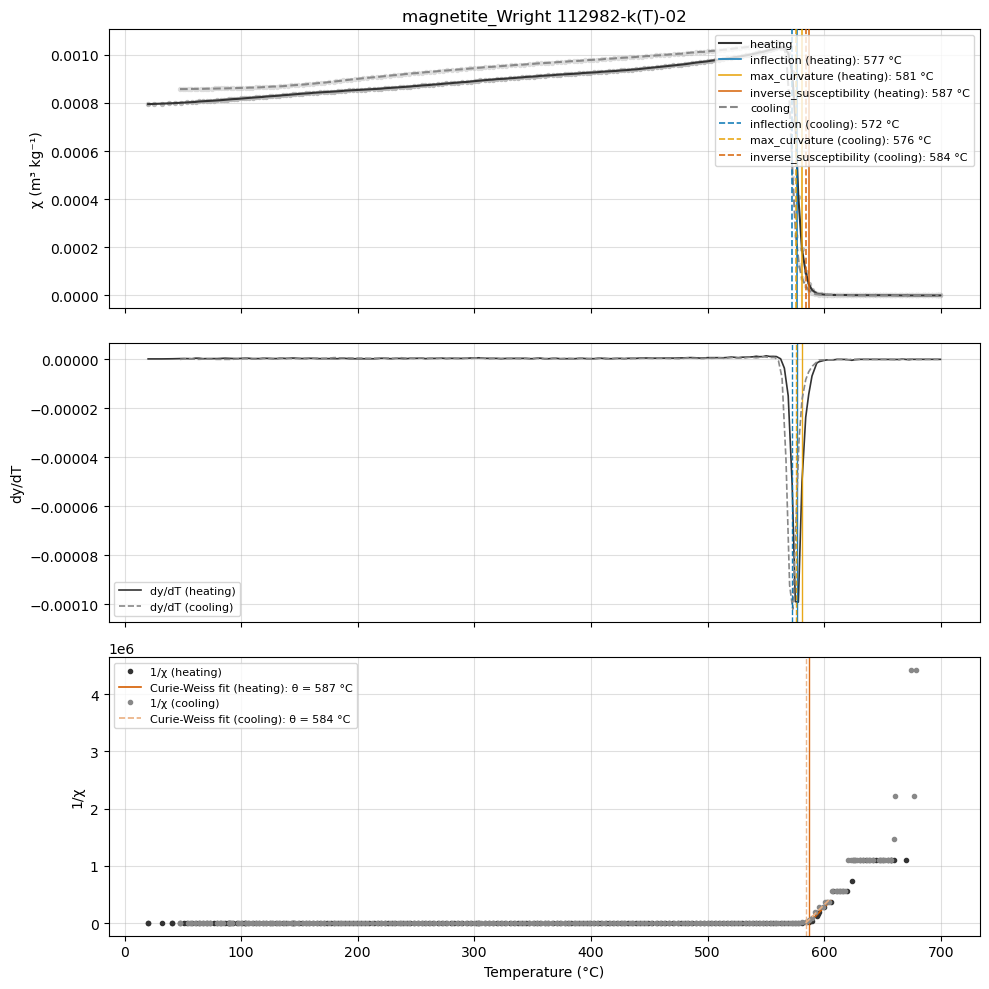

In [9]:
rmag.plot_curie_estimates(
    selected_experiment,
    smooth_window=10,
    method_kwargs={'inverse_susceptibility': {'fit_range': (585, 606)}},
    figsize=(10, 10),
);

The heating-branch inflection (~577 °C) and maximum-curvature (~581 °C) estimates bracket the accepted magnetite Curie temperature of 580 °C. The steep, step-like decrease of $\chi$(*T*) at the transition in a (near-)multidomain magnetite is dominated by the loss of the self-demagnetization-limited susceptibility plateau, and for such curves the derivative-based estimates on the descending step are close to *T*$_c$ ([Fabian et al., 2013](https://doi.org/10.1029/2012GC004440)). The Curie-Weiss fit over the resolved 585–606 °C interval yields $\theta \approx$ 587 ± 1 °C, consistent with the requirement $\theta \geq$ *T*$_c$ and with $\theta$ exceeding *T*$_c$ by several degrees for a ferrimagnet. The cooling-branch estimates differ from the heating branch by a few degrees; larger heating-cooling differences (irreversibility) signal alteration of the magnetic mineralogy during heating, in which case the cooling branch reflects the altered assemblage, not the original one.

### The two-tangent construction on $\chi$(*T*): shown only to be discouraged

Requesting `two_tangent` on susceptibility data attaches the caveat to the output. On this curve the two-tangent intersection lands close to the derivative estimates because the transition is sharp, but on curves with a pronounced Hopkinson peak or a rounded transition it can overestimate *T*$_c$ considerably ([Petrovský and Kapička, 2006](https://doi.org/10.1029/2006JB004507)) — and there is no physical justification for it on low-field susceptibility even when it happens to agree.

In [10]:
two_tangent_chi = rmag.curie_temperature_estimates(
    selected_experiment, methods=('two_tangent',), smooth_window=10)
two_tangent_chi[['branch', 'method', 'curie_temp', 'notes']]

,branch,method,curie_temp,notes
0,heating,two_tangent,582.824211,two-tangent intersection on susceptibility lac...
1,cooling,two_tangent,577.993777,two-tangent intersection on susceptibility lac...


### Interactive Curie-Weiss fitting

The draggable fit tool below helps identify the temperature interval over which 1/$\chi$ is linear (i.e., where the signal is fully paramagnetic): drag the two endpoints and the extrapolated $\theta$ updates live. This tool is for exploration; for reported values, feed the interval identified here to `curie_inverse_susceptibility` (or the `method_kwargs` of `curie_temperature_estimates`) so the fit is reproducible.

In [11]:
rmag.curie_inverse_susceptibility_interactive(
    selected_experiment,
    smooth_window=10,
    initial_fit_range=(585, 606),
)

### A Curie transition inside the MPMS window: titanomagnetite TM78

For titanomagnetite compositions with x $\gtrsim$ 0.75, the Curie temperature falls below room temperature, and the *entire* transition is captured by low-temperature MPMS susceptibility measurements. The TM78 sample from the Rock Magnetic Bestiary shows the susceptibility rising through a Hopkinson-like peak and collapsing near 265 K. The same estimator functions apply — only the temperature range differs.

Note `remove_holder=False` here: the default holder correction subtracts the per-branch minimum, which assumes the signal decays to a background level at the highest temperatures. For this specimen the branch minimum is the still-substantial paramagnetic susceptibility above the transition, not a holder background, so subtracting it would distort the curve.

In [12]:
tm78_experiment = measurements[(measurements['experiment'] ==
                                'IRM-OldBlue-LP-X:LP-X-T:LP-X-F:LP-X-H-9764')].reset_index(drop=True)
# use the 1 Hz in-phase susceptibility
tm78_1hz = tm78_experiment[np.isclose(tm78_experiment['meas_freq'].astype(float), 1.0)].reset_index(drop=True)

tm78_estimates = rmag.curie_temperature_estimates(
    tm78_1hz, temp_unit='K', methods=('inflection', 'max_curvature'), remove_holder=False)
tm78_estimates[['branch', 'method', 'curie_temp', 'temp_unit']]

,branch,method,curie_temp,temp_unit
0,heating,inflection,265.334193,K
1,heating,max_curvature,270.000000,K


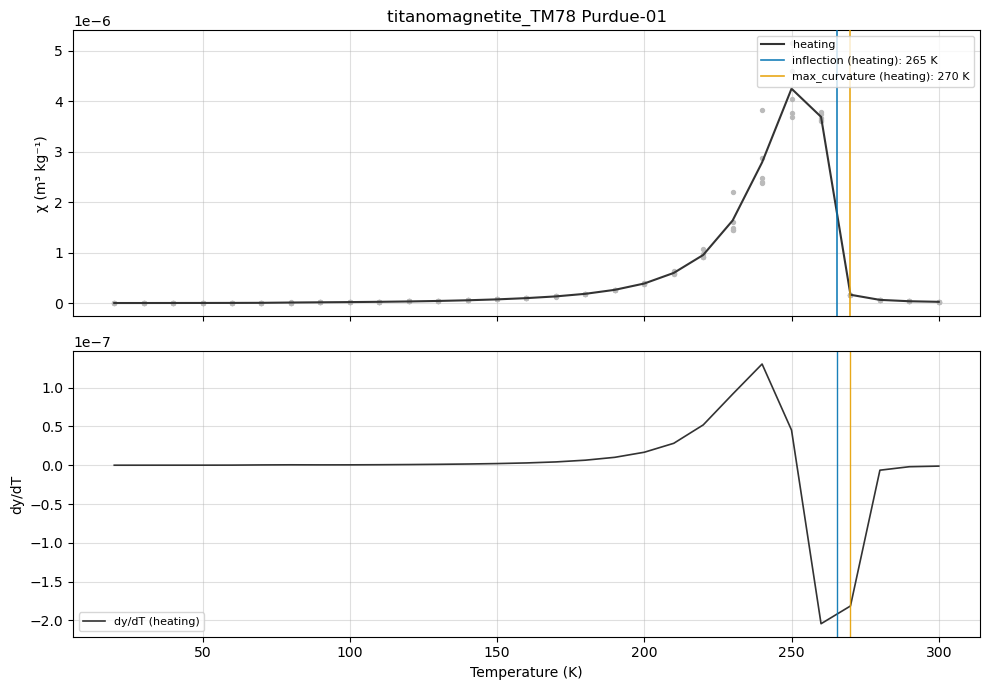

In [13]:
rmag.plot_curie_estimates(tm78_1hz, temp_unit='K', methods=('inflection', 'max_curvature'),
                          remove_holder=False, figsize=(10, 7));

## Part 3: Archiving the estimate in a MagIC specimens table

The MagIC data model stores critical temperatures in the specimens table: `critical_temp` (in kelvin) with `critical_temp_type` from the controlled vocabulary (here `'Curie'`). `rmag.add_curie_estimates_to_specimens_table` writes the chosen estimate and records the estimation method, branch, and uncertainty in the `description` column, so that the processing choice is archived with the result.

Rows are matched on the specimens table's `experiments` column, which in this contribution abbreviates the experiment name to `'IRM-KappaF-3410'` (the measurements table uses the longer `'IRM-KappaF-LP-X-T-3410'`), so we pass the name as it appears in the specimens table. If no experiment name matches, the function falls back to matching the specimen name and warns.

This contribution already archives a critical temperature for this specimen (849.70 K from a d$\chi$/dT minimum on heating): our heating-branch inflection estimate of 849.82 K (576.7 °C) reproduces it to within ~0.1 K, a satisfying independent check before overwriting the row.

In [14]:
specimens = contribution.tables['specimens'].df.reset_index(drop=True)

rmag.add_curie_estimates_to_specimens_table(
    specimens,
    experiment_name='IRM-KappaF-3410',
    estimates=curie_estimates,
    method='inflection',
    branch='heating',
)
specimens[specimens['specimen'] == 'magnetite_Wright 112982-k(T)-02'][
    ['specimen', 'experiments', 'critical_temp', 'critical_temp_type', 'description']]

,specimen,experiments,critical_temp,critical_temp_type,description
59,magnetite_Wright 112982-k(T)-02,NaN,NaN,NaN,NaN
193,magnetite_Wright 112982-k(T)-02,IRM-KappaF-3410,849.824623,Curie,dk/dT minimum on heating; {'curie_method': 'in...
194,magnetite_Wright 112982-k(T)-02,IRM-KappaF-3410,849.824623,Curie,dk/dT minimum on heating; {'curie_method': 'in...


## Summary

- Curie temperature estimates are method-dependent; report the method (and any smoothing/fitting windows) with the value.
- For in-field *M*(*T*) curves: the inflection point is the physically grounded estimate; maximum-curvature and two-tangent values run systematically high; the Landau fit adds a formal uncertainty; for runs that end below *T*$_c$, the *M*$_s^2$ extrapolation of Moskowitz (1981) is available, with reliability decaying as the gap to *T*$_c$ grows.
- For $\chi$(*T*) curves: derivative-based estimates on the descending step and the inverse-susceptibility (Curie-Weiss) extrapolation are appropriate; the two-tangent construction is not; and $\theta$ from 1/$\chi$ is an upper bound on *T*$_c$.
- Comparing estimates across methods (and between heating and cooling branches) is itself diagnostic — of *T*$_c$ distributions, alteration, and data quality.

## References

- Ade-Hall, J., Wilson, R., and Smith, P. (1965), The petrology, Curie points and natural magnetizations of basic lavas, *Geophysical Journal International*, 9, 323-336.
- Fabian, K., Shcherbakov, V. P., and McEnroe, S. A. (2013), Measuring the Curie temperature, *Geochemistry, Geophysics, Geosystems*, 14, 947-961, [doi:10.1029/2012GC004440](https://doi.org/10.1029/2012GC004440).
- Grommé, C. S., Wright, T. L., and Peck, D. L. (1969), Magnetic properties and oxidation of iron-titanium oxide minerals in Alae and Makaopuhi lava lakes, Hawaii, *Journal of Geophysical Research*, 74, 5277-5294, [doi:10.1029/JB074i022p05277](https://doi.org/10.1029/JB074i022p05277).
- Lattard, D., Engelmann, R., Kontny, A., and Sauerzapf, U. (2006), Curie temperatures of synthetic titanomagnetites in the Fe-Ti-O system: Effects of composition, crystal chemistry, and thermomagnetic methods, *Journal of Geophysical Research*, 111, B12S28, [doi:10.1029/2006JB004591](https://doi.org/10.1029/2006JB004591).
- Moskowitz, B. M. (1981), Methods for estimating Curie temperatures of titanomaghemites from experimental Js-T data, *Earth and Planetary Science Letters*, 53, 84-88, [doi:10.1016/0012-821X(81)90028-5](https://doi.org/10.1016/0012-821X(81)90028-5).
- Petrovský, E., and Kapička, A. (2006), On determination of the Curie point from thermomagnetic curves, *Journal of Geophysical Research*, 111, B12S27, [doi:10.1029/2006JB004507](https://doi.org/10.1029/2006JB004507).